# Model Project

## 1. Labor supply

Import and set magics:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import Worker
reload(Worker) # reload to ensure latest version is used as i was having problem
from Worker import Workerclass

import Government
reload(Government)
from Government import Governmentclass

import time
from scipy.optimize import minimize_scalar
from scipy.optimize import root_scalar

from math import isfinite

# autoreload modules when code is run
%load_ext autoreload
%autoreload 2



We consider workers indexed by $i$. Each worker has productivity $p_i > 0$ and chooses
labor supply measured in hours $\ell_i \in [0,\bar{\ell}]$, where $\bar{\ell}$ is the maximum
number of hours. Post-tax income is

\begin{equation}
y_i = y(p_i,\ell_i) = (1-\tau) w p_i \ell_i - \zeta, 
\tag{1}
\end{equation}

where $w$ is the real wage, $\tau \in [0,1)$ is a proportional tax rate, and $\zeta$ is a
lump-sum tax (or transfer if negative).

All workers have the same preferences, and their utility is
\begin{equation}
U(p_i,c_i,\ell_i) = \log c_i - \nu \frac{\ell_i^{1+\epsilon}}{1+\epsilon}.
\tag{2}
\end{equation}

They thus solve the following optimization problem:
\begin{equation}
V(p_i) = \max_{c_i>0,\;\ell_i \in [0,\bar{\ell}]} U(p_i,c_i,\ell_i) 
\tag{3}
\end{equation}

subject to \
$y_i = (1-\tau) w p_i \ell_i - \zeta$, \
$c_i = y_i$,

where $c_i$ is consumption, and $\epsilon > 0$ and $\nu > 0$.

To ensure positive consumption, the worker must choose
\begin{equation}*
\ell_i > \underline{\ell}_i \equiv \max\left\{ \frac{\zeta}{(1-\tau) w p_i},\,0 \right\}.
\end{equation}*

Then the optimization problem can also be written as
\begin{equation}
V(p_i) = \max_{\ell_i \in (\underline{\ell}_i,\bar{\ell}]} U\big(p_i,(1-\tau) w p_i \ell_i - \zeta,\ell_i\big)
\tag{4}
\end{equation}

The first order condition (FOC) for $\ell_i$ is
\begin{equation}
\phi(p_i,c_i,\ell_i) \equiv \frac{(1-\tau) w p_i}{c_i} - \nu \ell_i^{\epsilon} = 0.
\tag{5}
\end{equation}
If there is no solution to the FOC in $({\ell}_i,\bar{\ell}]$ then $\ell_i = \bar{\ell}_i$.

The calibration is $\bar{\ell} = 16$, $w = 1$, $\tau = 0.5$, $\zeta = 0.1$, $\epsilon = 1$ and
$\nu = 0.015$.








## 1.1 Numerical optimizer vs root-finder

1.Plot $U(p_i, c_i, \ell_i)$ with $c_i = y(p_i, \ell_i)$ for $\ell_i$ between $0.5$ and $\bar\ell$.

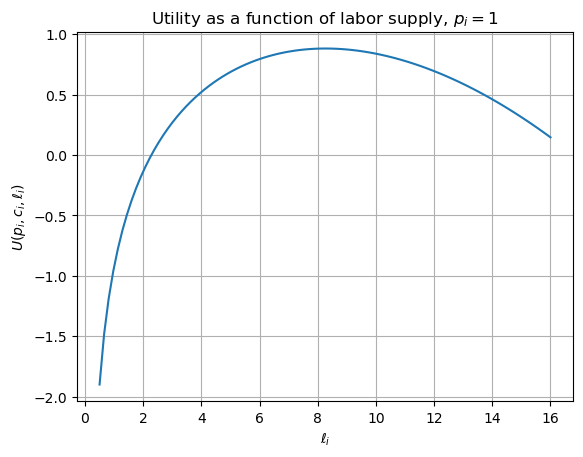

In [2]:
# create worker with default parameters
worker = Workerclass()

# choose productivity p_i = 1
p = 1.0

# grid for ℓ_i between 0.5 and ℓ̄
ell_grid = np.linspace(0.5, worker.par.ell_max, 100) #ell_grid is array of 100 values
# 4. compute c_i = y(p_i, ℓ_i) using the class, and then utility
c = worker.post_tax_income(p, ell_grid)   # c_i = y(p_i, ℓ_i)  
# compute utility using the class
U_vals = worker.utility(c, ell_grid)          # U(p_i, c_i, ℓ_i)
  


# 5. make the plot
plt.figure()
plt.plot(ell_grid, U_vals)
plt.xlabel(r'$\ell_i$')
plt.ylabel(r'$U(p_i, c_i, \ell_i)$')
plt.title(r'Utility as a function of labor supply, $p_i = 1$')
plt.grid(True)
plt.show()

2.Plot $\phi(p_i, c_i, \ell_i)$ with $c_i = y(p_i, \ell_i)$ for $\ell_i$ between $0.5$ and $\bar\ell$.

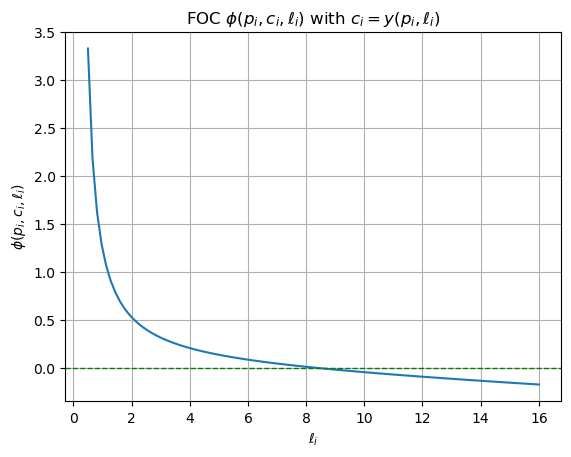

In [3]:
par = worker.par

# compute c_i = y(p_i, ℓ_i) (post-tax income) for all ℓ_i
c_vals = worker.post_tax_income(p, ell_grid)

# compute φ(p_i, c_i, ℓ_i) for all ℓ_i
phi_vals = (1 - par.tau) * par.w * p / c_vals - par.nu * ell_grid**par.epsilon

# plot φ as a function of ℓ
plt.figure()
plt.plot(ell_grid, phi_vals)
plt.axhline(0.0, color='g', linestyle='--', linewidth=1)  # FOC=0 line
plt.xlabel(r'$\ell_i$')
plt.ylabel(r'$\phi(p_i, c_i, \ell_i)$')
plt.title(r'FOC $\phi(p_i, c_i, \ell_i)$ with $c_i = y(p_i,\ell_i)$')
plt.grid(True)
plt.show()

3. Find the optimal $\ell^{\ast}(p_i)$ using a numerical optimizer to solve eq. 4

In [4]:
opt_num = worker.optimal_choice(p)
opt_num.ell = float(opt_num.ell)
opt_num.c   = float(opt_num.c)
opt_num.U   = float(opt_num.U)
print(f"l* = {opt_num.ell},  c* = {opt_num.c},  U* = {opt_num.U}")

l* = 8.265578140757935,  c* = 4.032789070378968,  U* = 0.8820598485935285


4. Find the optimal $\ell^{\ast}(p_i)$ using a root-finder to solve eq. 5

In [5]:
opt_root = worker.optimal_choice_FOC(p)
print(f"l* = {opt_root.ell},  c* = {opt_root.c},  U* = {opt_root.U}")

l* = 8.265578158750735,  c* = 4.032789079375368,  U* = 0.8820598485935285


5. Compare the results from the numerical optimizer and the root-finder, including
which of the methods is fastest

In [6]:
# -------- Numerical optimize
t0 = time.time()
opt_num = worker.optimal_choice(p)
t_num = time.time() - t0
# -------- Root-finder --------
t0 = time.time()
opt_root = worker.optimal_choice_FOC(p)
t_root = time.time() - t0
print("Numerical optimizer:")
print(f"  l* = {float(opt_num.ell):.6f}")
print(f"  c* = {float(opt_num.c):.6f}")
print(f"  U* = {float(opt_num.U):.6f}")
print(f"  Time = {t_num*1000:.4f} ms\n")

print("Root-finder:")
print(f"  l* = {float(opt_root.ell):.6f}")
print(f"  c* = {float(opt_root.c):.6f}")
print(f"  U* = {float(opt_root.U):.6f}")
print(f"  Time = {t_root*1000:.4f} ms\n")



Numerical optimizer:
  l* = 8.265578
  c* = 4.032789
  U* = 0.882060
  Time = 0.1938 ms

Root-finder:
  l* = 8.265578
  c* = 4.032789
  U* = 0.882060
  Time = 0.0682 ms



Both the numerical optimizer and the root-finder return essentially identical optimal values for labor supply $\ell^{\ast}$, consumption $c^{\ast}$, and utility $U^{\ast}$. The root-finder is faster.
This is because the optimizer performs a bounded search over the entire interval 
$[\ell_{\min},\,\ell_{\max}]$, while the root-finder solves a single scalar 
equation using Brent's method, which is more efficient in one dimension.

6. Combine everything in a single figure (multiple plots are allowed).  
Repeat the above for $\epsilon = 0.75$ and $\epsilon = 0.50$ while writing as little new code as possible.


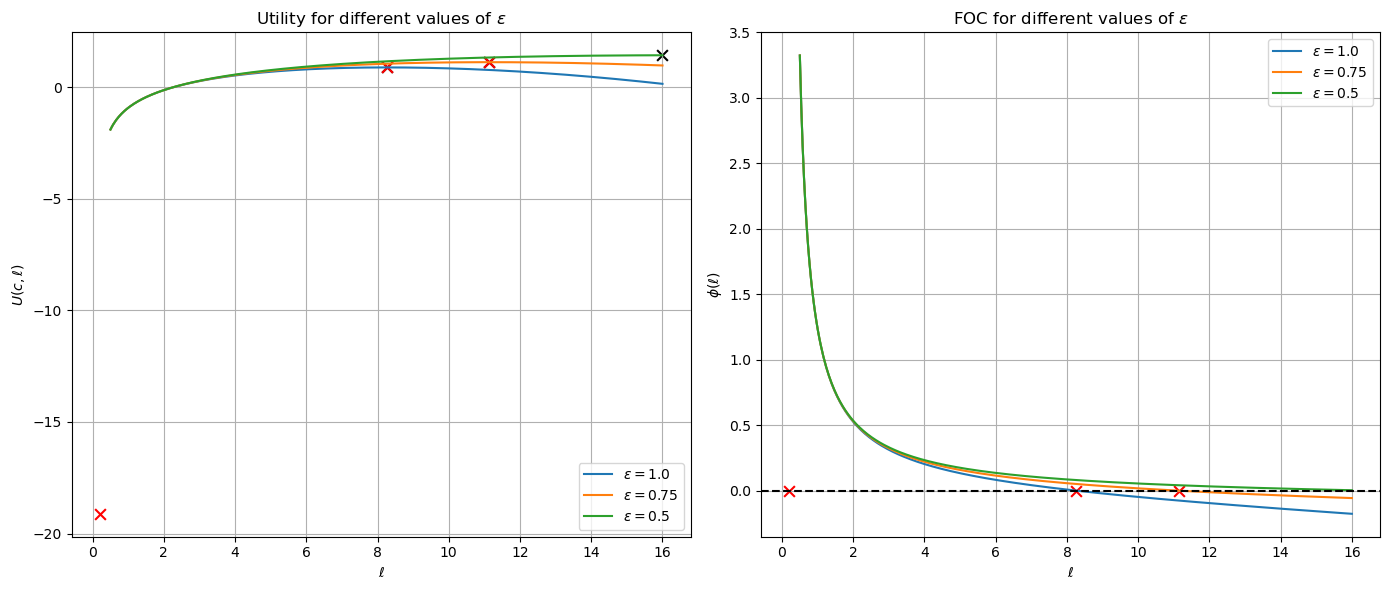

In [7]:
# fixed productivity
p = 1.0

# different epsilon values
eps_values = [1.0, 0.75, 0.50]

# create figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# left plot: Utility
# right plot: FOC
axU, axFOC = axes

# colors for consistency
colors = ['tab:blue', 'tab:orange', 'tab:green']

for eps, col in zip(eps_values, colors):

    # create worker with this ε
    worker = Workerclass({'epsilon': eps})

    # ℓ grid
    ells = np.linspace(0.5, worker.par.ell_max, 400)

    # compute utility and FOC values
    Uvals = [worker.value_of_choice(p, ell) for ell in ells]
    phivals = [worker.FOC(p, ell) for ell in ells]

    # optimal by optimizer
    opt_num  = worker.optimal_choice(p)

    # optimal by root-finder
    opt_foc  = worker.optimal_choice_FOC(p)

    # -------------------------------------------------------
    # PLOT 1 (left): Utility curves
    # -------------------------------------------------------
    axU.plot(ells, Uvals, color=col, label=f"$\\epsilon={eps}$")

    # mark the two computed optimal ℓ*
    axU.scatter([opt_num.ell], [opt_num.U], color='black', marker='x', s=60)
    axU.scatter([opt_foc.ell], [opt_foc.U], color='red', marker='x', s=60)

    # -------------------------------------------------------
    # PLOT 2 (right): FOC curves
    # -------------------------------------------------------
    axFOC.plot(ells, phivals, color=col, label=f"$\\epsilon={eps}$")

    # mark zero of FOC
    axFOC.scatter([opt_foc.ell], [0], color='red', marker='x', s=60)

# -------------------------------------------------------
# formatting LHS (Utility)
# -------------------------------------------------------
axU.set_title("Utility for different values of $\\epsilon$")
axU.set_xlabel("$\\ell$")
axU.set_ylabel("$U(c,\\ell)$")
axU.legend()
axU.grid(True)

# -------------------------------------------------------
# formatting RHS (FOC)
# -------------------------------------------------------
axFOC.set_title("FOC for different values of $\\epsilon$")
axFOC.set_xlabel("$\\ell$")
axFOC.set_ylabel("$\\phi(\\ell)$")
axFOC.axhline(0, color='black', linestyle='--')
axFOC.legend()
axFOC.grid(True)

plt.tight_layout()
plt.show()

## 1.2 Labor supply function

1. Find the optimal $\ell^{\ast}(p_i)$ for $p_i$ from 0.5 to 3.0 and plot the results.

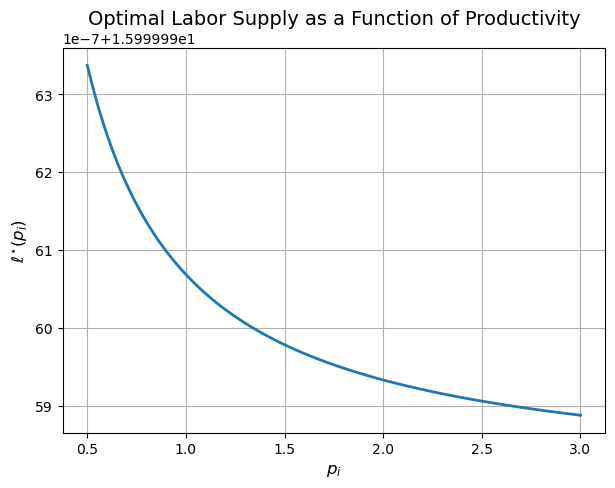

In [8]:
# range of productivities
ps = np.linspace(0.5, 3.0, 100)

# compute ℓ*(p) using the optimizer
ell_stars = np.array([worker.optimal_choice(p).ell for p in ps])

# plot
plt.figure(figsize=(7,5))
plt.plot(ps, ell_stars, linewidth=2)
plt.xlabel("$p_i$", fontsize=12)
plt.ylabel("$\\ell^{\\star}(p_i)$", fontsize=12)
plt.title("Optimal Labor Supply as a Function of Productivity", fontsize=14)
plt.grid(True)
plt.show()

2. Find the optimal $\ell^{\ast}(p_i)$ for $p_i$ from 0.5 to 3.0 when $\zeta = -0.1$ and plot the results.

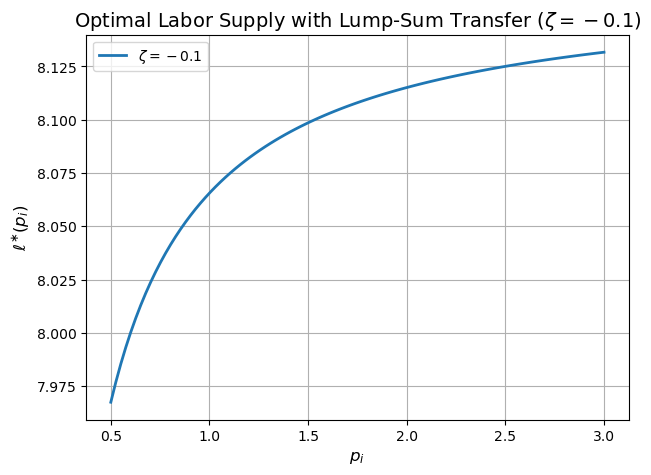

In [9]:
# Worker with ζ = -0.1
worker_transfer = Workerclass({'zeta': -0.1})

# productivity range
ps = np.linspace(0.5, 3.0, 100)

# compute ℓ*(p) under ζ = -0.1
ell_stars_transfer = np.array([worker_transfer.optimal_choice(p).ell for p in ps])

# plot
plt.figure(figsize=(7,5))
plt.plot(ps, ell_stars_transfer, linewidth=2, label="$\\zeta=-0.1$")
plt.xlabel("$p_i$", fontsize=12)
plt.ylabel("$\\ell^{\\ast}(p_i)$", fontsize=12)
plt.title("Optimal Labor Supply with Lump-Sum Transfer ($\\zeta = -0.1$)", fontsize=14)
plt.grid(True)
plt.legend()
plt.show()

## 2. Public good

We now consider an economy with $N$ workers and a government. Productivity is
log-normally distributed
\begin{equation}
\log p_i \sim \mathcal{N}\!\left(-\tfrac{1}{2}\sigma_p^2,\;\sigma_p^2\right),
\tag{6}
\end{equation}
and workers behave as described above. We now denote the optimal labor choice by
$\ell^{\star}(p_i; \tau, \zeta)$ to indicate it depends on the government’s choice of
the tax system. The implied utility is similarly denoted by $U(p_i; \tau, \zeta)$.

Total tax revenue is
\begin{equation}
T(\tau,\zeta) \;=\; N\zeta + \sum_{i=1}^{N} \tau w p_i \,\ell_i^{\star}(p_i;\tau,\zeta).
\tag{7}
\end{equation}
The government must have non-negative tax revenue, $T(\tau,\zeta) \geq 0$. Let
$\underline{p}$ be the smallest value of $p_i$ in the population. The government does
not impose a lump-sum tax that some individuals cannot pay. Therefore
\begin{equation}
\zeta < (1-\tau) w \,\underline{p}\,\ell.
\tag{8}
\end{equation}
The government uses tax revenue to finance a public good $G(\tau,\zeta) = T(\tau,\zeta)$.
The government seeks to optimize a so-called Social Welfare Function (SWF) given by
the sum of all utilities and a value of the public good,
\begin{equation}
\mathrm{SWF}(\tau,\zeta)
  = \chi {G(\tau,\zeta)^{\eta}}+ \sum_{i=1}^{N} U(p_i;\tau,\zeta).
\tag{9}
\end{equation}
The calibration is $N = 100$, $\sigma_p = 0.3$, $\chi = {1/2}{N}$ and
$\eta = 0.1$.








## 2.1 Tax revenue and SocialWelfare Function

1. Compute $T(\tau,\zeta)$ and $\mathrm{SWF}(\tau,\zeta)$ for $\tau = 0.50$ and $\zeta = 0.1$.}



In [10]:
# 1. Create government object
gov = Governmentclass()

# 2. Set the tax parameters
gov.par.tau = 0.50
gov.par.zeta = 0.1

# 3. Draw productivity for all workers
gov.draw_productivities()

# 4. Solve worker labor supply, consumption, utility
gov.solve_workers()

# 5. Compute total tax revenue T(τ, ζ)
T = gov.tax_revenue()


# 6. Compute social welfare SWF(τ, ζ)
SWF = gov.SWF()

print("Tax Revenue T =", T)
print("Social Welfare SWF =", SWF)

Tax Revenue T = 417.91177845246506
Social Welfare SWF = 174.04529656948384


2. Plot $T(\tau,\zeta)$ and $\mathrm{SWF}(\tau,\zeta)$ for $\zeta \in \{-0.1,\,0.0,\,0.1\}$ and for $\tau$ between $0.01$ and $0.80$.
3. Indicate in your plot where $\mathrm{SWF}(\tau,\zeta)$ is maximized for your current evaluations.

zeta = -0.1: tau* = 0.0815, SWF* = 222.2715
zeta =  0.0: tau* = 0.0695, SWF* = 222.2163
zeta =  0.1: tau* = 0.0576, SWF* = 222.1511


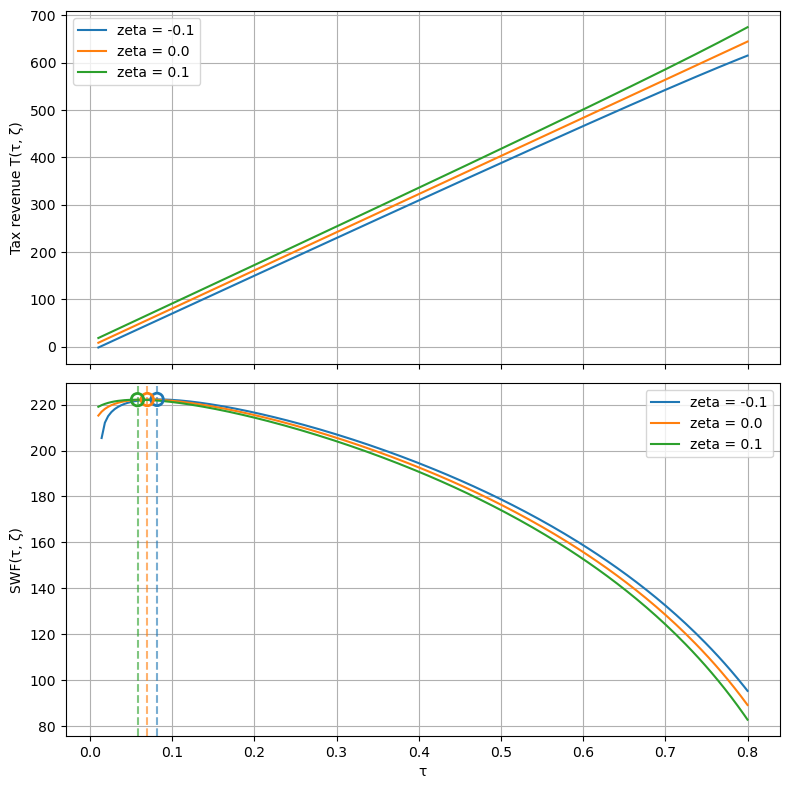

In [11]:
gov = Governmentclass()
par = gov.par


gov.draw_productivities()
p_fixed = gov.sol.p.copy()


taus  = np.linspace(0.01, 0.80, 200)
zetas = [-0.1, 0.0, 0.1]

T_results   = {}
SWF_results = {}

fig, axs = plt.subplots(2, 1, figsize=(8, 8), sharex=True)

colors = {-0.1: 'tab:blue', 0.0: 'tab:orange', 0.1: 'tab:green'}
for zeta in zetas:
    par.zeta = zeta
    gov.sol.p = p_fixed  

    T_vals   = np.zeros_like(taus)
    SWF_vals = np.zeros_like(taus)

    for j, tau in enumerate(taus):
        par.tau = tau

        gov.solve_workers()
        T_vals[j]   = gov.tax_revenue()
        SWF_vals[j] = gov.SWF()

    T_results[zeta]   = T_vals
    SWF_results[zeta] = SWF_vals

    color = colors[zeta]
    label = f"zeta = {zeta}"
    axs[0].plot(taus, T_vals,   label=label)
    axs[1].plot(taus, SWF_vals, color=color, label=label)

    # 2.1.3 find tau* that maximizes SWF(τ, ζ)
    valid      = np.isfinite(SWF_vals)
    taus_valid = taus[valid]
    swf_valid  = SWF_vals[valid]
    idx_max    = np.argmax(swf_valid)
    tau_max    = taus_valid[idx_max]
    swf_max    = swf_valid[idx_max]

    print(f"zeta = {zeta:4.1f}: tau* = {tau_max:.4f}, SWF* = {swf_max:.4f}")
    # mark optimal point on SWF plot
    axs[1].scatter(tau_max, swf_max,
                   s=80, facecolors='none', edgecolors=color,
                   linewidths=2, zorder=5)
    axs[1].axvline(tau_max, color=color, linestyle='--', alpha=0.6)

# plot formatting
axs[0].set_ylabel("Tax revenue T(τ, ζ)")
axs[0].legend()
axs[0].grid(True)

axs[1].set_xlabel("τ")
axs[1].set_ylabel("SWF(τ, ζ)")
axs[1].legend()
axs[1].grid(True)

plt.tight_layout()
plt.show()



## 2.2 Optimal tax system

1. Use a numerical optimizer to find the optimal tax system 

$\tau^{\ast},\zeta^{\ast} = \arg\max_{\tau \in [0,1),\;\zeta \in (-\infty,(1-\tau) w_{p}\ell)}\mathrm{SWF}(\tau,\zeta)$


In [12]:
gov = Governmentclass()
res = gov.optimal_taxes()


print(f"tau*  = {gov.par.tau:.4f}")
print(f"zeta* = {gov.par.zeta:.4f}")
print(f"max SWF ≈ {-res.fun:.4f}")

tau*  = 0.1368
zeta* = -0.5239
max SWF ≈ 222.3841


2. Verify that your choice of starting values for the numerical optimizer do not
matter for the result

In [13]:
par = gov.par

# 1. different starting values for (tau0, zeta0)
start_values = [
    (0.05, -0.1),
    (0.10,  0.0),
    (0.30,  0.1),
    (0.60, -0.05),
    (0.80,  0.0)
]

results = []

for tau0, zeta0 in start_values:
    res = gov.optimal_taxes(tau0 = tau0, zeta0=zeta0)

    tau_star  = gov.par.tau
    zeta_star = gov.par.zeta
    swf_star  = -res.fun

    results.append((tau0, zeta0, tau_star, zeta_star, swf_star, res.success))

    print(f"start (tau0={tau0:.2f}, zeta0={zeta0:.2f}) "
          f"--> tau*={tau_star:.5f}, zeta*={zeta_star:.5f}, "
          f"SWF*={swf_star:.5f}, success={res.success}")
    

tau_stars  = np.array([r[2] for r in results])
zeta_stars = np.array([r[3] for r in results])

same_tau  = np.allclose(tau_stars,  tau_stars[0],  atol=1e-4)
same_zeta = np.allclose(zeta_stars, zeta_stars[0], atol=1e-4)

print("All tau* equal (up to 1e-4)?  ", same_tau)
print("All zeta* equal (up to 1e-4)? ", same_zeta)

start (tau0=0.05, zeta0=-0.10) --> tau*=0.13682, zeta*=-0.52382, SWF*=222.38407, success=True
start (tau0=0.10, zeta0=0.00) --> tau*=0.10000, zeta*=-0.00000, SWF*=221.65450, success=True
start (tau0=0.30, zeta0=0.10) --> tau*=0.13678, zeta*=-0.52364, SWF*=222.38407, success=True
start (tau0=0.60, zeta0=-0.05) --> tau*=0.56051, zeta*=-2.16303, SWF*=208.90056, success=True
start (tau0=0.80, zeta0=0.00) --> tau*=0.13679, zeta*=-0.52365, SWF*=222.38407, success=True
All tau* equal (up to 1e-4)?   False
All zeta* equal (up to 1e-4)?  False


3. Plot $T(\tau,\zeta)$ and $\mathrm{SWF}(\tau,\zeta)$ for values close to $(\tau^{\ast}, \zeta^{\ast})$.

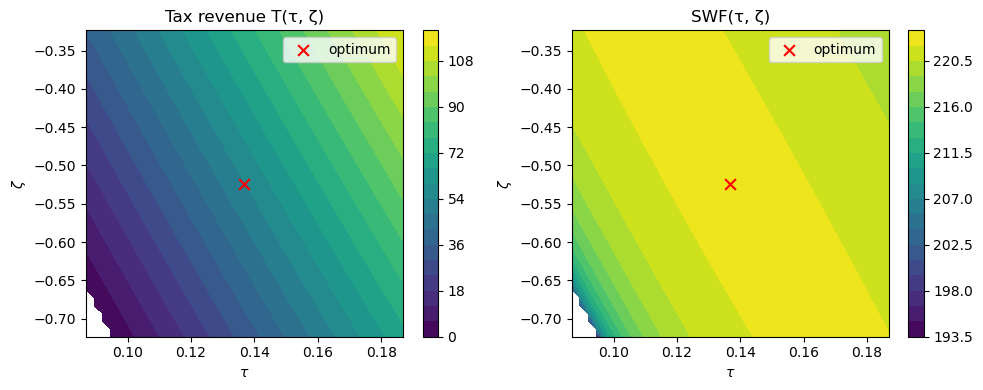

In [14]:
par = gov.par
sol = gov.sol

# fix productivity
if not hasattr(sol, 'p'):
    gov.draw_productivities()
p_fixed = sol.p.copy()

# First step: build the value grids near (tau*, zeta*)
tau_min = max(0.0,  tau_star - 0.05)
tau_max = min(0.8,  tau_star + 0.05)
zeta_min = zeta_star - 0.2
zeta_max = zeta_star + 0.2

taus_local  = np.linspace(tau_min,  tau_max, 40)
zetas_local = np.linspace(zeta_min, zeta_max, 40)

T_grid   = np.zeros((len(zetas_local), len(taus_local)))
SWF_grid = np.zeros((len(zetas_local), len(taus_local)))

# Step 2: evaluate T(τ, ζ) and SWF(τ, ζ) on the grid
for i, zeta in enumerate(zetas_local):
    par.zeta = zeta
    sol.p = p_fixed 

    for j, tau in enumerate(taus_local):
        par.tau = tau

        gov.solve_workers()
        T_val   = gov.tax_revenue()
        SWF_val = gov.SWF()

        # either value is NaN or infinite, store NaN in the grid
        if not np.isfinite(T_val) or not np.isfinite(SWF_val):
            T_grid[i, j]   = np.nan
            SWF_grid[i, j] = np.nan
        else:
            T_grid[i, j]   = T_val
            SWF_grid[i, j] = SWF_val

# Step 3: make the plots
TAU, ZETA = np.meshgrid(taus_local, zetas_local)

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

# left：Tax revenue
cs1 = axs[0].contourf(TAU, ZETA, T_grid, levels=20)
axs[0].scatter(tau_star, zeta_star, color='red', marker='x', s=60, label='optimum')
axs[0].set_xlabel(r'$\tau$')
axs[0].set_ylabel(r'$\zeta$')
axs[0].set_title('Tax revenue T(τ, ζ)')
axs[0].legend()
fig.colorbar(cs1, ax=axs[0])

# right：SWF
cs2 = axs[1].contourf(TAU, ZETA, SWF_grid, levels=20)
axs[1].scatter(tau_star, zeta_star, color='red', marker='x', s=60, label='optimum')
axs[1].set_xlabel(r'$\tau$')
axs[1].set_ylabel(r'$\zeta$')
axs[1].set_title('SWF(τ, ζ)')
axs[1].legend()
fig.colorbar(cs2, ax=axs[1])

plt.tight_layout()
plt.show()


4. Plot the Lorenz curve of consumption when $\tau = \tau^{\ast}$ and $\zeta = \zeta^{\ast}$.

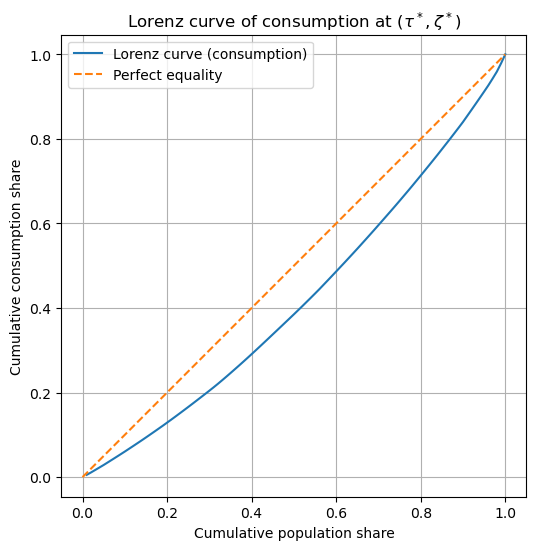

In [15]:
gov = Governmentclass()
par = gov.par
gov.solve_workers()
c = gov.sol.c.copy()
N = len(c)

# build Lorenz curve
c_sorted       = np.sort(c)  # sort consumption
cum_c  = np.cumsum(c_sorted)  # cumulative sum of sorted consumption
cum_c_share = cum_c / cum_c[-1] 
pop_share      = np.arange(1, N+1) / N

# plot Lorenz curve
plt.figure(figsize=(6,6))
plt.plot(pop_share, cum_c_share, label='Lorenz curve (consumption)')
plt.plot([0,1], [0,1], '--', label='Perfect equality')

plt.xlabel('Cumulative population share')
plt.ylabel('Cumulative consumption share')
plt.title(r'Lorenz curve of consumption at $(\tau^*, \zeta^*)$')
plt.grid(True)
plt.legend()
plt.axis('equal')
plt.show()

# 3 Top tax

## 3.1 Labor supply

In [16]:
# set top-tax parameters
par = worker.par
par.kappa = 9.0
par.omega = 0.2

# compute optimal taxes ONCE (from Q2)
res = gov.optimal_taxes()
tau_star  = gov.par.tau
zeta_star = gov.par.zeta

# make sure worker uses these taxes when you plot / compute FOCs
par.tau  = tau_star
par.zeta = zeta_star

w     = par.w
kappa = par.kappa
omega = par.omega


1.Plot $U(p_i, c_i, \ell_i)$ with $c_i = y(p_i, \ell_i)$ for $\ell_i$ between $0.5$ and $\bar\ell$.

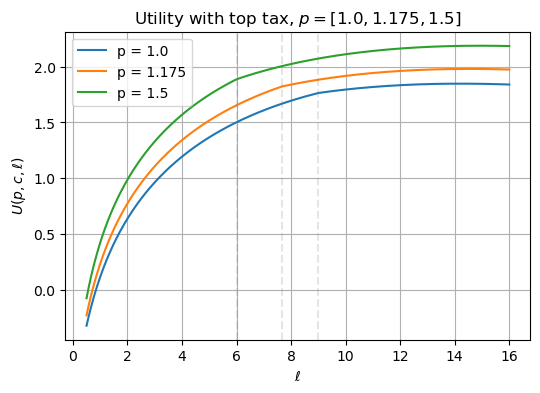

In [17]:
p_list = [1.0, 1.175, 1.5]

plt.figure(figsize=(6,4))
for p in p_list:
    # build wokring hours grid
    ells = np.linspace(0.5, par.ell_max, 400)
    y_pre = worker.income(p, ells)
    c_top = (1 - tau)*y_pre - omega*np.maximum(y_pre - kappa, 0) - zeta # consume all the post-tax income

    # only plot where c_top > 0
    mask = c_top > 0
    ells_plot = ells[mask]
    c_plot    = c_top[mask]

    # Utility values
    U = worker.utility(c_plot, ells_plot)
    plt.plot(ells_plot, U, label=f"p = {p}")
# plot the results
for p in p_list:
    ell_kink = kappa/(w*p)
    plt.axvline(ell_kink, color='gray', linestyle='--', alpha=0.2)

plt.xlabel(r'$\ell$')
plt.ylabel(r'$U(p,c,\ell)$')
plt.title(fr'Utility with top tax, $p={p_list}$')
plt.legend()
plt.grid(True)
plt.show()

2. Plot $ \underline{\varphi}(p_i, c_i, \ell_i)$ with $c_i = y(p_i, \ell_i)$ for $\ell_i$ between $0.5$ and $\frac{\kappa}{wp}$. 
3. Plot $ \bar{\varphi}(p_i, c_i, \ell_i)$ with $c_i = y(p_i, \ell_i)$ for $\ell_i$ between $\frac{\kappa}{wp}$ and $\bar{\ell}$.

<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
<>:31: SyntaxWarning: invalid escape sequence '\e'
<>:32: SyntaxWarning: invalid escape sequence '\e'
/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_73246/2633311952.py:31: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(ells, phi_b, label='FOC $\ell\in[0.5,\kappa/(wp)]$')
/var/folders/7z/npwd4mkj50g10rrf3zlkgr4m0000gn/T/ipykernel_73246/2633311952.py:32: SyntaxWarning: invalid escape sequence '\e'
  plt.plot(ells, phi_a, label='FOC $\ell\in[\kappa/(wp),\\bar\ell]$')


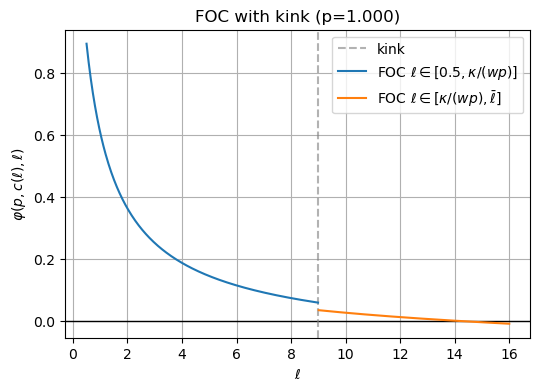

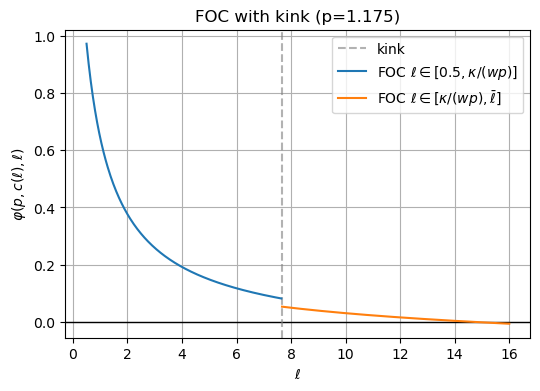

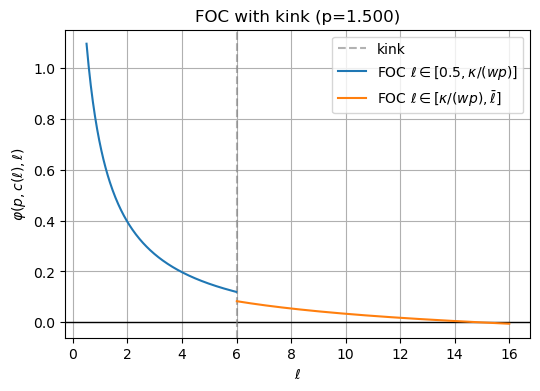

In [18]:
p_list = [1.0, 1.175, 1.5]

def c_top(p, ell):
    y = w*p*ell
    return (1 - tau_star)*y - omega*np.maximum(y - kappa, 0) - zeta_star

def phi_before(p, ell):  # (11) region: ell < kappa/(wp)
    c = (1 - tau_star)*w*p*ell - zeta_star
    if np.any(c <= 0):
        return np.nan
    return (1 - tau_star)*w*p/c - par.nu*ell**par.epsilon

def phi_after(p, ell):   # (12) region: ell > kappa/(wp)
    c = c_top(p, ell)
    if np.any(c <= 0):
        return np.nan
    return (1 - tau_star - omega)*w*p/c - par.nu*ell**par.epsilon

for p in p_list:

    ell_k = kappa/(w*p)
    ells  = np.linspace(0.5, par.ell_max, 600)

    phi_b = np.array([phi_before(p, ell) if ell < ell_k else np.nan for ell in ells])
    phi_a = np.array([phi_after(p,  ell) if ell > ell_k else np.nan for ell in ells])

    plt.figure(figsize=(6,4))
    plt.axhline(0, color='black', linewidth=1)
    plt.axvline(ell_k, color='gray', linestyle='--', alpha=0.6, label='kink')

    plt.plot(ells, phi_b, label='FOC $\ell\in[0.5,\kappa/(wp)]$')
    plt.plot(ells, phi_a, label='FOC $\ell\in[\kappa/(wp),\\bar\ell]$')

    plt.xlabel(r'$\ell$')
    plt.ylabel(r'$\varphi(p,c(\ell),\ell)$')
    plt.title(fr'FOC with kink (p={p:.3f})')
    plt.grid(True)
    plt.legend()
    plt.show()


 4. Find the optimal $\ell^*(pi)$ using a numerical optimizer

In [19]:
def c_top(p, ell):
    tau   = tau_star
    zeta  = zeta_star
    w     = par.w
    kappa = par.kappa
    omega = par.omega
    y_pre = worker.income(p, ell)
    return (1 - tau)*y_pre - omega*np.maximum(y_pre - kappa, 0) - zeta # consume all the post-tax income


def U_top(p, ell):
    c = c_top(p, ell)
    if c <= 0:
        return -1e10
    return worker.utility(c, ell)

def optimal_choice_top(p):
    def obj(ell):
        return -U_top(p, ell)
    
    res = minimize_scalar(
        obj,
        bounds=(0.0, par.ell_max),   
        method='bounded'
    )

    ell_star = res.x
    c_star   = c_top(p, ell_star)
    U_star   = U_top(p, ell_star)

    return ell_star, c_star, U_star, res

for p in [1.0, 1.175, 1.5]:
    ell_star, c_star, U_star, res = optimal_choice_top(p)
    print(f"p = {p:.3f}: ell* = {ell_star:.4f}, c* = {c_star:.4f}, U* = {U_star:.4f}")


p = 1.000: ell* = 14.1922, c* = 11.7358, U* = 1.9280
p = 1.175: ell* = 14.5158, c* = 13.6350, U* = 2.0596
p = 1.500: ell* = 14.9221, c* = 17.1678, U* = 2.2666


5. Find the optimal $\ell^*(p_i)$ using the four step first order condition approach described above

In [20]:
worker = Workerclass()
gov = Governmentclass()
par_w = worker.par
par_g = gov.par

# set up tax parameters
par_w.kappa = 9.0
par_w.omega = 0.2

# find the optimal tax rate 
res = gov.optimal_taxes()
tau   = par_g.tau
zeta  = par_g.zeta

w        = par_w.w
nu       = par_w.nu
epsilon  = par_w.epsilon
kappa    = par_w.kappa
omega    = par_w.omega
ell_max  = par_w.ell_max

def c_top(p, ell):
    y_pre = worker.income(p, ell)
    return (1 - tau)*y_pre - omega*np.maximum(y_pre - kappa, 0) - zeta # consume all the post-tax income

# First step: FOC below kink (ell < kappa/(wp))
def phi_below(p, ell):
    c = c_top(p, ell)
    if c <= 0:
        return np.nan
    return (1 - tau) * w * p / c - nu * ell**epsilon
# Second and third steps: FOC above kink (ell >= kappa/(wp))
def phi_above(p, ell):
    c = c_top(p, ell)
    if c <= 0:
        return np.nan
    return (1 - tau - omega) * w * p / c - nu * ell**epsilon
# Find root between a and b
# If no root is found, return None
def find_root(fun, a, b):
    try:
        fa, fb = fun(a), fun(b)
        if not np.isfinite(fa) or not np.isfinite(fb) or fa*fb > 0:
            return None
        sol = root_scalar(fun, bracket=[a, b], method='brentq')
        if sol.converged:
            return sol.root
        else:
            return None
    except ValueError:
        return None
# Step 4: return optimal choices
def ell_star_FOC(p):
    # Kink point
    ell_kink = kappa / (w * p)

    # Below kink
    ell_b = None
    U_b   = -np.inf
    if ell_kink > 0.0:
        root_b = find_root(lambda ell: phi_below(p, ell), 0.0, ell_kink)
        if root_b is not None:
            c_b = c_top(p, root_b)
            if c_b > 0:
                U_b   = worker.utility(c_b, root_b)
                ell_b = root_b
    # kink point
    c_k = c_top(p, ell_kink)
    if c_k > 0:
        U_k = worker.utility(c_k, ell_kink)
    else:
        U_k = -np.inf
    # Above kink
    ell_a = None
    U_a   = -np.inf
    if ell_max > ell_kink:
        root_a = find_root(lambda ell: phi_above(p, ell),
                           ell_kink + 1e-8, ell_max)
        if root_a is not None:
            c_a = c_top(p, root_a)
            if c_a > 0:
                U_a   = worker.utility(c_a, root_a)
                ell_a = root_a
    # Compare the three candidates
    candidates = [(U_b, ell_b, 'b'),
                  (U_k, ell_kink, 'k'),
                  (U_a, ell_a, 'a')]
    U_star, ell_star, region = max(candidates, key=lambda x: x[0])
    c_star = c_top(p, ell_star) if ell_star is not None else None

    return ell_star, c_star, U_star, {
        'ell_b': ell_b, 'U_b': U_b,
        'ell_k': ell_kink, 'U_k': U_k,
        'ell_a': ell_a, 'U_a': U_a,
        'region': region
    }

# try different productivities
p_list = [1.0, 1.175, 1.5]

for p in p_list:
    ell_star, c_star, U_star, info = ell_star_FOC(p)
    print(f"p = {p:.3f}: l*_FOC = {ell_star:.4f}, c* = {c_star:.4f}, U* = {U_star:.4f}, region = {info['region']}")

p = 1.000: l*_FOC = 7.8672, c* = 7.3146, U* = 1.5257, region = b
p = 1.175: l*_FOC = 7.6596, c* = 8.2925, U* = 1.6753, region = k
p = 1.500: l*_FOC = 7.0800, c* = 9.3668, U* = 1.8612, region = a


6. Compare the results from the numerical optimizer and the root-finder, includ-
ing which of the methods is fastest

In [21]:
p_list = [1.0, 1.175, 1.5]

print("=== Compare levels ===")
for p in p_list:
    # numerical optimizer
    t0 = time.perf_counter()
    ell_num, c_num, U_num, res_num = optimal_choice_top(p)
    t1 = time.perf_counter()

    # FOC 4-step
    ell_foc, c_foc, U_foc, info = ell_star_FOC(p)
    t2 = time.perf_counter()

    print(f"p = {p:.3f}")
    print(f"  ell*_num = {ell_num:.6f},  ell*_FOC = {ell_foc:.6f},  diff = {ell_num-ell_foc:.2e}")
    print(f"  U_num    = {U_num:.6f},  U_FOC    = {U_foc:.6f},  diff = {U_num-U_foc:.2e}")
    print(f"  time_num = {(t1-t0)*1e3:.2f} ms,  time_FOC = {(t2-t1)*1e3:.2f} ms")
    print(f"  FOC region = {info['region']}  # b=below, k=kink, a=above")
    print()


=== Compare levels ===
p = 1.000
  ell*_num = 7.867150,  ell*_FOC = 7.867150,  diff = -9.19e-09
  U_num    = 1.525683,  U_FOC    = 1.525683,  diff = 0.00e+00
  time_num = 0.13 ms,  time_FOC = 0.06 ms
  FOC region = b  # b=below, k=kink, a=above

p = 1.175
  ell*_num = 7.659575,  ell*_FOC = 7.659574,  diff = 4.87e-07
  U_num    = 1.675328,  U_FOC    = 1.675328,  diff = -1.02e-08
  time_num = 0.17 ms,  time_FOC = 0.01 ms
  FOC region = k  # b=below, k=kink, a=above

p = 1.500
  ell*_num = 7.080044,  ell*_FOC = 7.080043,  diff = 7.23e-07
  U_num    = 1.861224,  U_FOC    = 1.861224,  diff = -6.66e-15
  time_num = 0.09 ms,  time_FOC = 0.04 ms
  FOC region = a  # b=below, k=kink, a=above



7. Combine everything in a single figure (multiple plots are allowed)

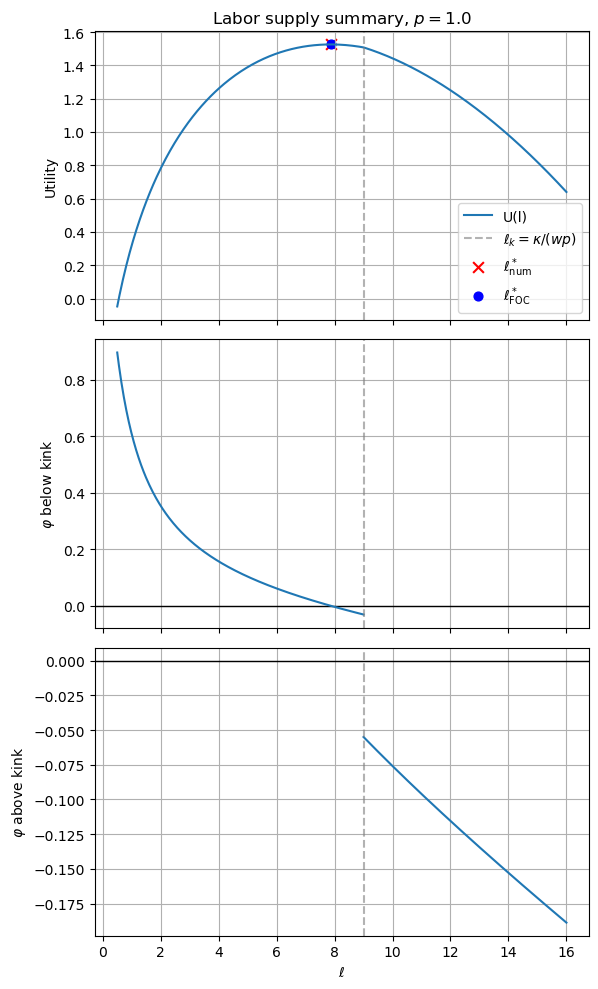

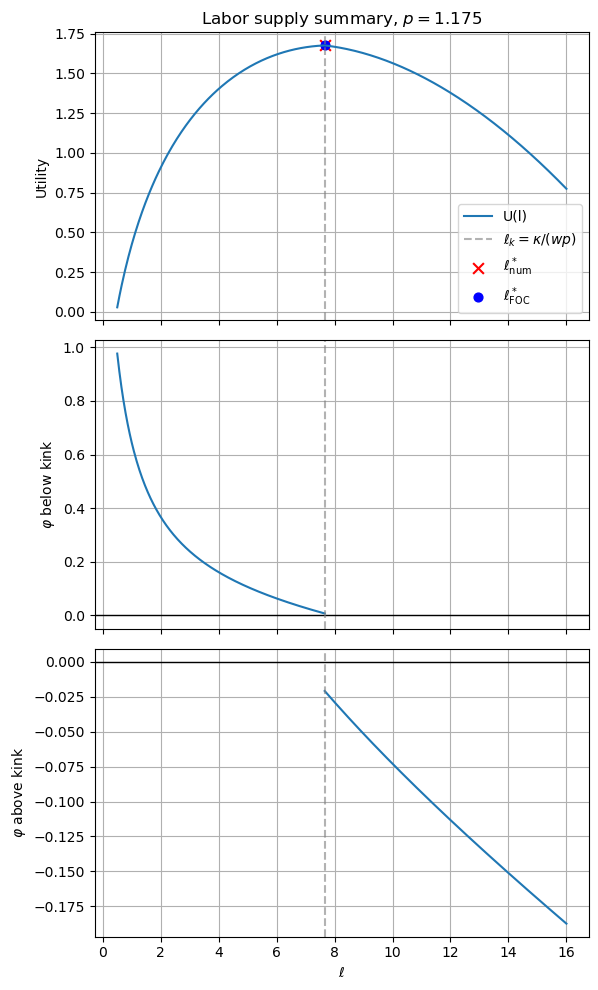

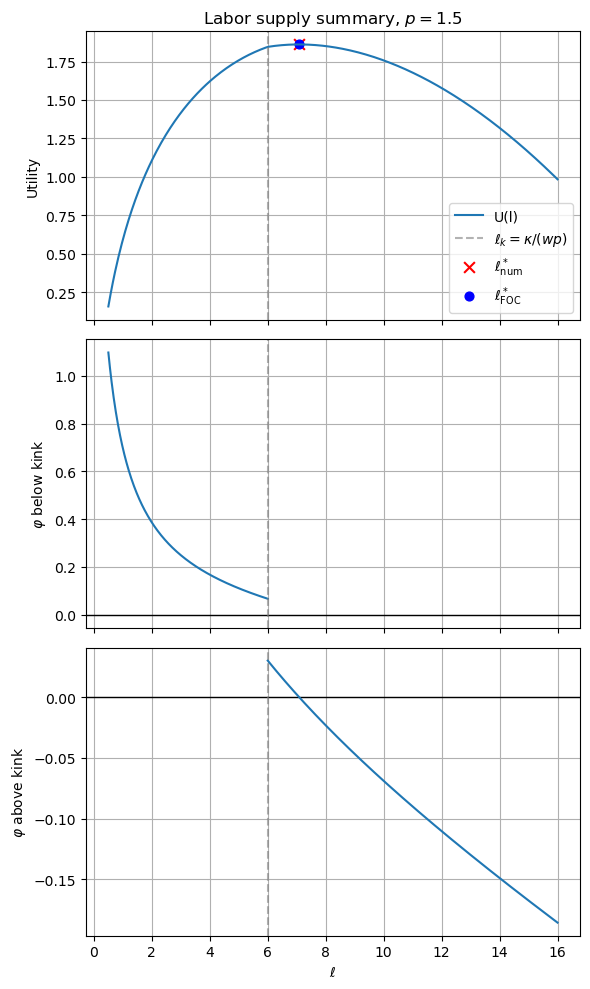

In [22]:
def plot_summary_for_p(p):
    # parameters
    par = worker.par
    w       = par.w
    kappa   = par.kappa
    ell_max = par.ell_max
    
    # kink point
    ell_k = kappa / (w * p)
    
    # ========================
    # 0. Solve for l*_num, l*_FOC
    # ========================
    ell_num, c_num, U_num, _ = optimal_choice_top(p)
    ell_foc, c_foc, U_foc, info = ell_star_FOC(p)
    
    # ========================
    # 1. Compute grids for U(l), φ below and above kink
    # ========================
    ells = np.linspace(0.5, ell_max, 400)
    c_vals  = np.array([c_top(p, ell) for ell in ells])
    U_vals  = np.where(c_vals > 0, worker.utility(c_vals, ells), np.nan)
    
    # φ below: in [0.5, min(ell_k, ell_max)]
    ells_b = np.linspace(0.5, min(ell_k, ell_max), 300)
    phi_b  = np.array([phi_below(p, ell) for ell in ells_b])
    
    # φ above: in [ell_k, ell_max]
    ells_a = np.linspace(ell_k, ell_max, 300)
    phi_a  = np.array([phi_above(p, ell) for ell in ells_a])
    
    # ========================
    # 2. Plot 3×1 subplots
    # ========================
    fig, axes = plt.subplots(3, 1, figsize=(6, 10), sharex=True)
    
    # (a) Utility
    ax = axes[0]
    ax.plot(ells, U_vals, label='U(l)')
    ax.axvline(ell_k, color='gray', linestyle='--', alpha=0.6,
               label=r'$\ell_k = \kappa/(wp)$') # this is the kink point
    ax.scatter([ell_num], [U_num], color='red',  marker='x', s=60,
               label=r'$\ell^*_{\mathrm{num}}$') # optimal from numerical optimizer
    ax.scatter([ell_foc], [U_foc], color='blue', marker='o', s=40,
               label=r'$\ell^*_{\mathrm{FOC}}$') # optimal from FOC method
    ax.set_ylabel('Utility')
    ax.set_title(fr'Labor supply summary, $p = {p}$')
    ax.grid(True)
    ax.legend(loc='best')
    
    # (b) φ below kink
    ax = axes[1]
    ax.axhline(0, color='black', linewidth=1) # φ=0 line (optimality)
    ax.plot(ells_b, phi_b)
    ax.axvline(ell_k, color='gray', linestyle='--', alpha=0.6) # kink point
    ax.set_ylabel(r'$\varphi$ below kink')
    ax.grid(True)
    
    # (c) φ above kink
    ax = axes[2]
    ax.axhline(0, color='black', linewidth=1)
    ax.plot(ells_a, phi_a)
    ax.axvline(ell_k, color='gray', linestyle='--', alpha=0.6)
    ax.set_ylabel(r'$\varphi$ above kink')
    ax.set_xlabel(r'$\ell$')
    ax.grid(True)
    
    plt.tight_layout()
    plt.show()
for p in [1.0, 1.175, 1.5]:
    plot_summary_for_p(p)


## 3.2 Labor supply function

1. Plot both $\ell^*(p_i)$ and the implied $c_i = y(p_i,\ell_i)$ for $p_i$ between 0.5 and 3.0

tau* = 0.1368, zeta* = -0.5239


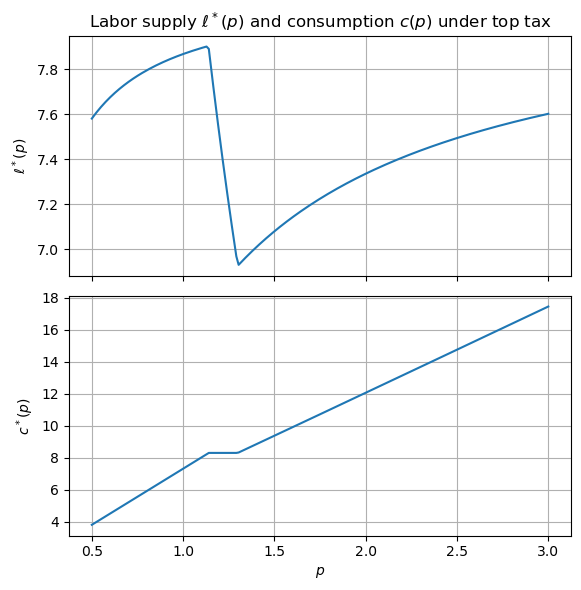

In [23]:
# Same as before: find optimal tax rates

tau_star  = par_g.tau
zeta_star = par_g.zeta

print(f"tau* = {tau_star:.4f}, zeta* = {zeta_star:.4f}")

# 2. productivity grid
ps = np.linspace(0.5, 3.0, 200)

ells_star = np.zeros_like(ps)
c_star    = np.zeros_like(ps)

# compute l*(p) and c*(p) using the 4-step FOC method
for i, p in enumerate(ps):
    ell_opt, c_opt, U_opt, info = ell_star_FOC(p)
    ells_star[i] = ell_opt
    c_star[i]    = c_opt

# 3. plot results
fig, axs = plt.subplots(2, 1, figsize=(6, 6), sharex=True)

# panel 1: labor supply function
axs[0].plot(ps, ells_star)
axs[0].set_ylabel(r'$\ell^*(p)$')
axs[0].set_title(r'Labor supply $\ell^*(p)$ and consumption $c(p)$ under top tax')
axs[0].grid(True)

# panel 2: implied consumption
axs[1].plot(ps, c_star)
axs[1].set_xlabel(r'$p$')
axs[1].set_ylabel(r'$c^*(p)$')
axs[1].grid(True)

plt.tight_layout()
plt.show()


2. What proportions of workers has $\ell^*(p_i) = l_i^b$, $l^*(p_i) = l_i^k$ and $l^*(p_i) = l_i^a$?

In [24]:
ps = np.linspace(0.5, 3.0, 100)

# Proportion of workers 
counts = {'b': 0, 'k': 0, 'a': 0}

for p in ps:
    ell_star, c_star, U_star, info = ell_star_FOC(p)
    region = info['region']   # 'b', 'k', or 'a'
    counts[region] += 1

N = len(ps)
props = {reg: counts[reg] / N for reg in counts}

print("Counts:", counts)
print("Proportions:")
print(f"  share with l* = l_b(p): {props['b']:.3f}")
print(f"  share with l* = l_k(p): {props['k']:.3f}")
print(f"  share with l* = l_a(p): {props['a']:.3f}")

Counts: {'b': 26, 'k': 6, 'a': 68}
Proportions:
  share with l* = l_b(p): 0.260
  share with l* = l_k(p): 0.060
  share with l* = l_a(p): 0.680


## 3.3 Public good

1. How does the value of the SWF change when introducing the top tax rate?

In [25]:
import numpy as np
from scipy.optimize import minimize_scalar

# -------------------------
# 0) Fix productivity distribution
# -------------------------
if not hasattr(gov.sol, 'p'):
    gov.draw_productivities()
p_fixed = gov.sol.p.copy()
N = len(p_fixed)

# -------------------------
# 1) Baseline: no top tax (linear tax only)
# -------------------------
gov.sol.p = p_fixed
gov.solve_workers()
SWF_no_top = gov.SWF()
print(f"SWF without top tax = {SWF_no_top:.4f}")

# -------------------------
# 2) With top tax: kappa=9, omega=0.2
# -------------------------
kappa = 9.0
omega = 0.2
gov.par.kappa = worker.par.kappa = kappa
gov.par.omega = worker.par.omega = omega

par = worker.par
w, nu, eps, ell_max = par.w, par.nu, par.epsilon, par.ell_max

def c_top(p, ell):
    y = w*p*ell
    return (1 - tau_star)*y - omega*np.maximum(y - kappa, 0.0) - zeta_star

def U_top(p, ell):
    c = c_top(p, ell)
    if c <= 0:
        return -1e12
    return np.log(c) - nu * ell**(1+eps)/(1+eps)

def optimal_choice_top(p):
    ell_min = max(zeta_star / ((1 - tau_star)*w*p), 0.0) + 1e-8

    res = minimize_scalar(lambda ell: -U_top(p, ell),
                          bounds=(ell_min, ell_max),
                          method='bounded')
    ell_star = res.x
    c_star   = c_top(p, ell_star)
    U_star   = U_top(p, ell_star)
    return ell_star, c_star, U_star

Us_top = np.zeros(N)
Ts_top = np.zeros(N)

for i, p in enumerate(p_fixed):
    ell_star, c_star, U_star = optimal_choice_top(p)
    Us_top[i] = U_star

    y_pre = w*p*ell_star
    Ts_top[i] = y_pre - c_star   # tax = pre-tax income - post-tax income

G_top = Ts_top.sum()
SWF_top = Us_top.sum() + gov.par.chi*(G_top**gov.par.eta)

print(f"SWF with top tax (kappa=9, omega=0.2) = {SWF_top:.4f}")
print(f"ΔSWF = SWF_top - SWF_no_top = {SWF_top - SWF_no_top:.4f}")


SWF without top tax = 222.3841
SWF with top tax (kappa=9, omega=0.2) = 221.9336
ΔSWF = SWF_top - SWF_no_top = -0.4504


2. How does the Lorenz-curve for consumption change?

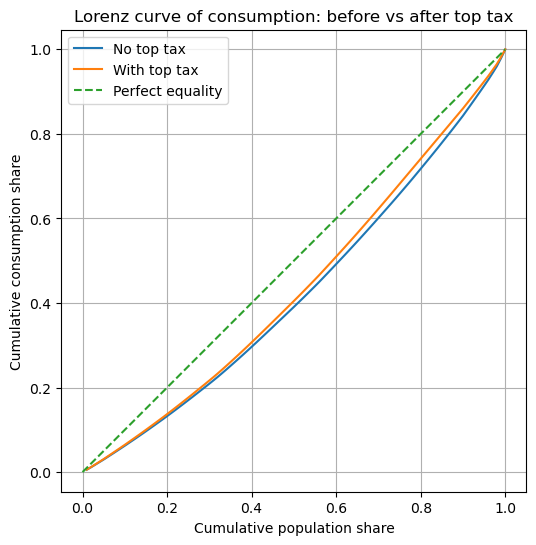

In [26]:

# No top tax scenario (baseline)
gov.sol.p = p_fixed
gov.solve_workers()
c_base = gov.sol.c.copy()

def lorenz_curve(c):
    c_sorted = np.sort(c)
    cum_c    = np.cumsum(c_sorted)
    pop_share = np.arange(1, len(c_sorted)+1) / len(c_sorted)   # population cumulative share
    cons_share = cum_c / cum_c[-1]                               # consumption cumulative share
    return pop_share, cons_share

pop_base, cons_base = lorenz_curve(c_base)

# Top tax scenario
par_w.kappa = 9.0
par_w.omega = 0.2
w = par_w.w

c_top_vec = np.zeros(N)
for i, p in enumerate(p_fixed):
    ell_star, c_star, U_star, info = ell_star_FOC(p)
    c_top_vec[i] = c_star
pop_top, cons_top = lorenz_curve(c_top_vec)

plt.figure(figsize=(6,6))
plt.plot(pop_base, cons_base, label='No top tax')
plt.plot(pop_top,  cons_top,  label='With top tax')
plt.plot([0,1], [0,1], '--', label='Perfect equality')

plt.xlabel('Cumulative population share')
plt.ylabel('Cumulative consumption share')
plt.title('Lorenz curve of consumption: before vs after top tax')
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.show()


Insight: even though the scenario without top tax has a better SWF, the redistribution effect is stronger in the top tax scenario.

3. Can you find a $\omega$ and $\kappa$ which implies an improvement in the SWF?

In [27]:
omega_grid = np.linspace(0.0, 1.0 - tau_star - 1e-3, 10) 
kappa_grid = np.linspace(5.0, 16.0, 10) 

best_SWF   = -1e18
best_omega = None
best_kappa = None

for omega in omega_grid:
    par_w.omega = omega
    for kappa in kappa_grid:
        par_w.kappa = kappa

        Us = np.zeros(N)
        Ts = np.zeros(N)

        # find optimal labor supply for each worker
        for i, p in enumerate(p_fixed):
            ell_star, c_star, U_star, info = ell_star_FOC(p)
            Us[i] = U_star

            y_pre = worker.income(p, ell_star)
            Ts[i] = y_pre - c_star

        G    = Ts.sum()
        if G < 0:   # if negative public revenue, skip
            continue
        SWF = par_g.chi * (G**par_g.eta) + Us.sum()

        if SWF > best_SWF:
            best_SWF   = SWF
            best_omega = omega
            best_kappa = kappa

print(f"Best (omega, kappa) on grid = ({best_omega:.3f}, {best_kappa:.3f})")
print(f"Max SWF on grid = {best_SWF:.4f}")


Best (omega, kappa) on grid = (0.000, 16.000)
Max SWF on grid = 222.3841


# 4. Extension 

* Now individual's preference is heterogeneous. 

* Some people prefer to work more $\rightarrow$ $\nu$ is low

* Some people prefer to work less $\rightarrow$ $\nu$ is high

* Working preference is lognormal distributed
\begin{equation*}
\log \nu_i \sim \mathcal{N}\!\left(\log \bar \nu -\tfrac{1}{2}\sigma_\nu^2,\;\sigma_\nu^2\right),
\end{equation*}

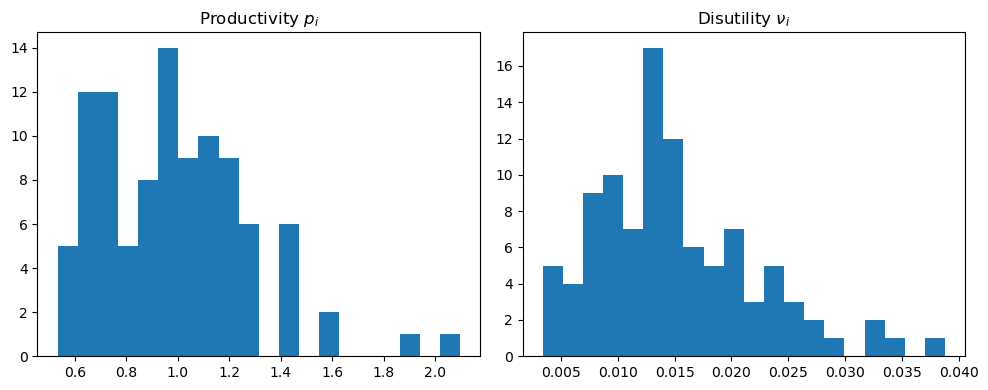

Extended model (heterogeneous nu):
  tau**  = 0.4041
  zeta** = -2.1957
  max SWF_ext ≈ 227.5188
Baseline model (homogeneous nu):
  tau*  = 0.1370
  zeta* = -0.5248
  max SWF ≈ 222.2044


In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

# 0) Create two government objects: one for heterogeneous nu, one for baseline
gov_het  = Governmentclass()
gov_base = Governmentclass()

# 1) Draw heterogeneous preferences
gov_het.rng = np.random.default_rng(12345)
gov_het.draw_preferences()

p_fixed  = gov_het.sol.p.copy()
nu_fixed = gov_het.sol.nu.copy()
N = len(p_fixed)

# 2) Plot the distributions of p_i and nu_i
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.hist(p_fixed, bins=20)
plt.title(r"Productivity $p_i$")

plt.subplot(1,2,2)
plt.hist(nu_fixed, bins=20)
plt.title(r"Disutility $\nu_i$")
plt.tight_layout()
plt.show()

# 3) Define function to compute optimal taxes under heterogeneous nu
def optimal_taxes_hetero(gov, p_fixed, nu_fixed, tau0=None, zeta0=None):

    par, sol = gov.par, gov.sol
    sol.p  = p_fixed
    sol.nu = nu_fixed

    p_min = p_fixed.min()

    if tau0 is None:  tau0 = par.tau
    if zeta0 is None: zeta0 = par.zeta
    x0 = np.array([tau0, zeta0])

    def obj(x):
        tau, zeta = x

        if tau < 0.0 or tau >= 0.999:
            return 1e12

        zeta_max = (1 - tau) * par.w * p_min * par.ell_max
        if zeta >= zeta_max:
            return 1e12

        par.tau  = tau
        par.zeta = zeta

        # Solve workers' problem
        gov.solve_workers_preference()

        SWF = gov.SWF()
        if not np.isfinite(SWF):
            return 1e12
        return -SWF

    bounds = [(0.0, 0.999), (-1e6, 1e6)]
    res = minimize(obj, x0, bounds=bounds, method='L-BFGS-B')

    par.tau  = float(res.x[0])
    par.zeta = float(res.x[1])
    return res

# 4) Extended model (heterogeneous nu)
res_ext = optimal_taxes_hetero(gov_het, p_fixed, nu_fixed)
tau_ext, zeta_ext = gov_het.par.tau, gov_het.par.zeta

print("Extended model (heterogeneous nu):")
print(f"  tau**  = {tau_ext:.4f}")
print(f"  zeta** = {zeta_ext:.4f}")
print(f"  max SWF_ext ≈ {-res_ext.fun:.4f}")

# 5) Baseline model (homogeneous nu): set nu_i = E[nu_i]
gov_base.sol.p = p_fixed.copy()
gov_base.par.nu = float(np.mean(nu_fixed))

res_base = gov_base.optimal_taxes()

print("Baseline model (homogeneous nu):")
print(f"  tau*  = {gov_base.par.tau:.4f}")
print(f"  zeta* = {gov_base.par.zeta:.4f}")
print(f"  max SWF ≈ {-res_base.fun:.4f}")


### Results
I extend the baseline model by introducing heterogeneous preferences over labor. Instead of a common disutility parameter $\nu$, each worker draws an individual $\nu_i$ from a log-normal distribution centered around the baseline value. Utility becomes
\begin{equation*}
U(p_i,c_i,\ell_i, \nu_i) = \log c_i - \nu_i \frac{\ell_i^{1+\epsilon}}{1+\epsilon}.
\end{equation*}
I keep the production side and the government’s SWF unchanged.

With heterogeneous $ \nu_i $ ($\sigma_\nu = 0.5$), the optimal tax parameters become
$(\tau^{**}, \zeta^{**}) = (0.4041, -2.1957)$, compared to the homogeneous-preference
benchmark $(\tau^{*}, \zeta^{*}) = (0.137, -0.524)$.
Labor supply becomes more dispersed: for a given productivity $p_i$, workers with
higher $ \nu_i $ work less, and those with lower $ \nu_i $ work more.
The resulting SWF is **higher** than in the baseline (about $227.5188$ vs. $222.2044$),
reflecting the fact that labor-supply distortions are effectively **less** costly when
some workers are relatively willing to work and can bear a larger share of the tax burden.


### Discussion: model/parameter selection (realism vs. feasibility)

In this extension, I introduce heterogeneity in preferences for labor by letting each worker draw an individual disutility-of-labor parameter $\nu_i$ from a log-normal distribution centered around the baseline value. The log-normal assumption is convenient because it guarantees $\nu_i>0$ and provides a parsimonious one-parameter way via $\sigma_\nu$ to generate dispersion in labor supply without changing the rest of the model. To keep the comparison clean, the homogeneous benchmark can be interpreted as using $\nu=\mathbb{E}[\nu_i]$, so differences in outcomes are driven by heterogeneity rather than a shift in average disutility.

The realism gain is that workers with the same productivity $p_i$ can supply different hours due to idiosyncratic tastes/costs of working, which matches the observed dispersion in labor supply in the data. The feasibility trade-off is that the heterogeneity parameter $\sigma_\nu$ is not disciplined by external evidence here: it is chosen mainly for illustration, and very large dispersion may create numerical issues (e.g., very low consumption for some agents). A more realistic specification would calibrate $\sigma_\nu$ (and potentially allow correlation between $\nu_i$ and productivity $p_i$ using micro evidence on wages and hours, but this would require additional data and would complicate identification and computation.

As a simple robustness check, one can vary $\sigma_\nu$ and verify whether the qualitative comparison of policies and welfare remains unchanged.
